In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Dataset limpio
df = pd.read_csv("../data/interim/IIEG_Seguridad_jalisco.csv")

# GeoJSON de municipios Jalisco
gdf = gpd.read_file("../data/raw/mun_jal.geojson")

In [3]:
#Vamos a seleccionar solo el último año
df_2025 = df[df["year"] == 2025]

#agregar delitos por municipio
delitos_2025 = (
    df_2025.groupby("municipio")
    .size()
    .reset_index(name="total_delitos")
)
#Estandarizar nombres
delitos_2025["municipio"] = delitos_2025["municipio"].str.upper().str.strip()
gdf["nomgeo"] = gdf["nomgeo"].str.upper().str.strip()

#Merge geoespacial
gdf_merged = gdf.merge(
    delitos_2025,
    left_on="nomgeo",
    right_on="municipio",
    how="left"
)

In [4]:
#Como no tenemos X y Y, calculamos los centroides
gdf_merged["total_delitos"] = gdf_merged["total_delitos"].fillna(0)

# Reproyectar antes de centroides, si no sabes cuál usar, EPSG:3857 funciona bien para visualización
gdf_proj = gdf_merged.to_crs(epsg=3857)

# Centroides ya en CRS proyectado
gdf_proj["centroid"] = gdf_proj.geometry.centroid

In [5]:
top3 = (
    gdf_proj[["nomgeo", "total_delitos"]]
    .sort_values("total_delitos", ascending=False)
    .head(3)
)

top3_text = "Top 3 municipios con más delitos (2025)\n"
for i, (_, row) in enumerate(top3.iterrows(), start=1):
    top3_text += f"{i}. {row['nomgeo']}: {int(row['total_delitos'])}\n"


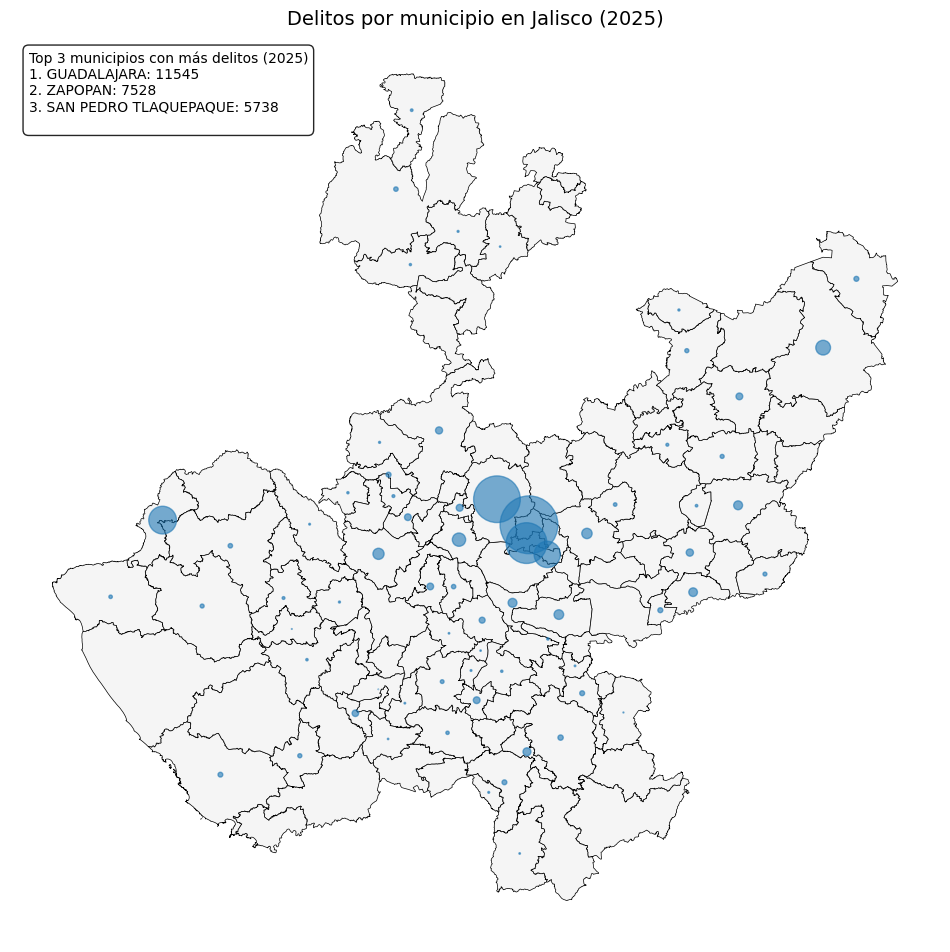

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))

# mapa base
gdf_proj.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.5)

# solo municipios con delitos > 0
gdf_valid = gdf_proj[gdf_proj["total_delitos"] > 0].copy()

ax.scatter(
    gdf_valid["centroid"].x,
    gdf_valid["centroid"].y,
    s=gdf_valid["total_delitos"] * 0.15,   # ajusta escala si lo ves muy grande o chico
    alpha=0.6
)

# título
ax.set_title("Delitos por municipio en Jalisco (2025)", fontsize=14)

# recuadro Top 3
ax.text(
    0.02, 0.98,
    top3_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.85)
)

ax.axis("off")
plt.show()

Número total de meses en amg_ratio: 110
Número de valores en x: 110

Meses por año:
year
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     2
dtype: int64

Suma de barras del histograma: 110


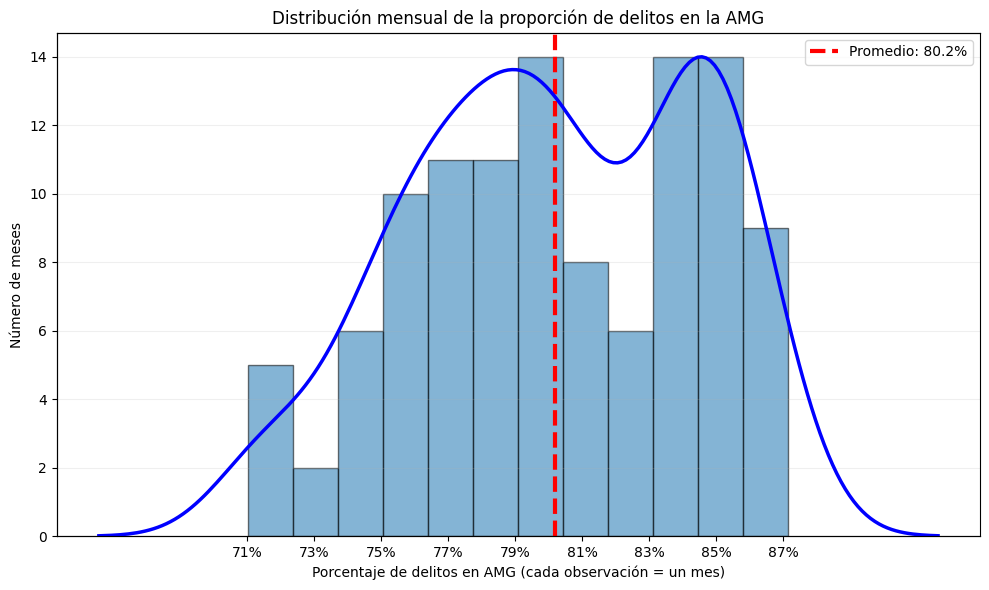

In [21]:
# ==========================================
# 1. Cargar datos
# ==========================================
df = pd.read_csv("../data/interim/IIEG_Seguridad_Jalisco.csv")

# ==========================================
# 2. Limpiar y crear variable AMG
# ==========================================
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.dropna(subset=["fecha", "zona_geografica"])

df["zona_geografica"] = df["zona_geografica"].astype(str).str.strip().str.upper()
df["is_amg"] = (df["zona_geografica"] == "AMG").astype(int)

# ==========================================
# 3. Calcular proporción mensual de delitos en AMG
# ==========================================
amg_ratio = (
    df.groupby(["year", "month"])["is_amg"]
      .mean()
      .reset_index(name="prop_amg")
)

# porcentaje
amg_ratio["prop_amg_pct"] = amg_ratio["prop_amg"] * 100
x = amg_ratio["prop_amg_pct"].dropna()

# ==========================================
# 4. Verificaciones
# ==========================================
print("Número total de meses en amg_ratio:", len(amg_ratio))
print("Número de valores en x:", len(x))
print("\nMeses por año:")
print(amg_ratio.groupby("year").size())

# ==========================================
# 5. Estadísticos
# ==========================================
mean_val = x.mean()
bins = 12

# ==========================================
# 6. Figura
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

counts, bin_edges, _ = ax.hist(
    x,
    bins=bins,
    edgecolor="black",
    alpha=0.55
)

print("\nSuma de barras del histograma:", int(counts.sum()))

# KDE en eje secundario
ax2 = ax.twinx()
sns.kdeplot(
    x=x,
    ax=ax2,
    color="blue",
    linewidth=2.5,
    fill=False,
    bw_adjust=0.9
)

ax2.set_ylabel("")
ax2.set_yticks([])
ax2.spines["right"].set_visible(False)

# Línea roja del promedio
ax.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=3,
    label=f"Promedio: {mean_val:.1f}%"
)

# Formato
ax.set_title("Distribución mensual de la proporción de delitos en la AMG")
ax.set_xlabel("Porcentaje de delitos en AMG (cada observación = un mes)")
ax.set_ylabel("Número de meses")

xmin = int(np.floor(x.min()))
xmax = int(np.ceil(x.max()))
xticks = np.arange(xmin, xmax + 1, 2)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{v}%" for v in xticks])

ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()